# Notebook to compute ZDR calibration offset for each campaign file

Last step of the method described by Ferrone and Berne, Remote Sensing, 2020.\
Requires to have previously run the **01_compute_filtered_dataframe.ipynb** and **02_compute_kriging.ipynb notebooks**.

In this notebook, the kriging coefficients derived before are used to compute the ZDR calibration offset for each campaign file.

*NC: this notebook was run on 03.07.2026 for final calculation of Zdr-correction for the CHOPIN campaign.*

In [1]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import datetime

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
# PARAMETERS
# Directory data
#CORR_DIR = 'corrections_kriging/'
#DATA_DIR = '/ltedata/ICEGENESIS_2021/Radar/Proc_data/'
#SAVE_DIR = '/ltenas8/campaigns/ICEGENESIS_2021/Zdr_calib/'

#campaign_name = 'ICEGENESIS_2021'
CORR_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/'
DATA_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/proc_data/L0_new'
SAVE_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606'

campaign_name = 'CHOPIN_2024'


In [3]:
# Get all scans to correct
def search_scans(dirname=DATA_DIR):
    '''
    Function for searching the scans datetime in the directory
    Adjust depending on file structure
    '''
    # all_scans = glob.glob(os.path.join(dirname, '20[0-2][0-9]', '*', '*', 'MXPol-*.nc')) 
    #all_scans = glob.glob(os.path.join(dirname, '20[0-2][0-9]', '*', '*', 'XPOL-*.nc')) 
    all_scans = glob.glob(os.path.join(dirname, '20[0-2][0-9]', '*', '*', 'XPOL-*.nc')) 
    # all_scans = sorted(glob.glob(dirname+'*.nc'))

    # Sorting the files, to be sure they are in chronological order
    all_scans.sort()
    return all_scans

In [4]:
# Get all date/time to correct
def extract_datetime(all_scans):
    dt_list = []
    dt_str_list = []
    #is_ppi_90 = []
    is_Zdr = []
    for scan in all_scans:
        curr_str_datetime = scan.split('/')[-1].split('_')[0]
        dt_str_list.append(curr_str_datetime)
        dt_list.append(datetime.datetime.strptime(curr_str_datetime, 'XPOL-%Y%m%d-%H%M%S').replace(tzinfo=datetime.timezone.utc).timestamp())
        #is_ppi_90.append('PPI' in scan)
        is_Zdr.append('Zdr' in scan)
    return dt_list, is_Zdr, dt_str_list

In [5]:
all_scans = search_scans(DATA_DIR)
dt_list, is_Zdr, dt_str_list = extract_datetime(all_scans)


In [6]:
dt_array = np.array(dt_list)
#ppi90_flag_list = np.array(is_ppi_90, dtype='bool')
ppi90_flag_list = np.array(is_Zdr, dtype='bool')

## Computing kriging correction

In [7]:
# Variogram models defined as the way preferred by pykrige
def spherical_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    fitted_variogram = nugget + par_sill * ((1.5 * x/rng) - (0.5 * np.power(x/rng, 3)))
    fitted_variogram[x > rng] = nugget + par_sill
    return fitted_variogram

def two_sperical_variogram(parameters, x):
    [rng1, par_sill1, rng2, par_sill2, nugget] = parameters
    fitted_variogram = nugget + par_sill1 * ((1.5 * x/rng1) - (0.5 * np.power(x/rng1, 3)))
    fitted_variogram[x > rng1] = nugget + par_sill1
    
    fitted_variogram += par_sill2 * ((1.5 * x/rng2) - (0.5 * np.power(x/rng2, 3)))
    fitted_variogram[x > rng2] = nugget + par_sill1 + par_sill2
    return fitted_variogram

def gaussian_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    a = rng / 1.7
    fitted_variogram = nugget + par_sill * (1. - np.exp(-np.square(x/a)))
    return fitted_variogram

def spherical_plus_gaussian_variogram(parameters, x):
    [rng_sph, par_sill_sph, rng_gau, par_sill_gau, nugget] = parameters
    fitted_variogram = nugget + par_sill_sph * ((1.5 * x/rng_sph) - (0.5 * np.power(x/rng_sph, 3)))
    fitted_variogram[x > rng_sph] = nugget + par_sill_sph
    
    a = rng_gau / 1.7
    fitted_variogram += par_sill_gau * (1. - np.exp(-np.square(x/a)))
    
    return fitted_variogram

def spherical_plus_exponential_variogram(parameters, x):
    [rng_sph, par_sill_sph, rng_exp, par_sill_exp, nugget] = parameters
    fitted_variogram = nugget + par_sill_sph * ((1.5 * x/rng_sph) - (0.5 * np.power(x/rng_sph, 3)))
    fitted_variogram[x > rng_sph] = nugget + par_sill_sph
    
    a = rng_exp / 3.
    fitted_variogram += par_sill_exp * (1. - np.exp(-x/a))
    
    return fitted_variogram

def exponential_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    a = rng / 3.
    fitted_variogram = nugget + par_sill * (1. - np.exp(-x/a))
    return fitted_variogram

def exponential_plus_gaussian_variogram(parameters, x):
    [rng_exp, par_sill_exp, rng_gau, par_sill_gau, nugget] = parameters
    
    a_exp = rng_exp / 3.
    fitted_variogram = nugget + par_sill_exp * (1. - np.exp(-x/a_exp))
    
    a_gau = rng_gau / 1.7
    fitted_variogram += par_sill_gau * (1. - np.exp(-np.square(x/a_gau)))
    
    return fitted_variogram

def exponential_plus_spherical_variogram(parameters, x):
    [rng_exp, par_sill_exp, rng_sph, par_sill_sph, nugget] = parameters
    
    a_exp = rng_exp / 3.
    fitted_variogram = nugget + par_sill_exp * (1. - np.exp(-x/a_exp))
    
    fitted_variogram[x <= rng_sph] += par_sill_sph * ((1.5 * x[x<=rng_sph]/rng_sph) - 
                                                      (0.5 * np.power(x[x<=rng_sph]/rng_sph, 3)))
    fitted_variogram[x > rng_sph] += par_sill_sph
    
    return fitted_variogram

def pure_nugget_variogram(parameters, x):
    [nugget] = parameters
    fitted_variogram = np.ones(x.shape)*nugget
    return fitted_variogram

# Redefinition as scipy standard
def spherical_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return spherical_variogram(parameters, x)

def two_sperical_variogram_scipy(x, rng1, sill1, rng2, sill2, nugget):
    parameters = [rng1, sill1, rng2, sill2, nugget]
    return two_sperical_variogram(parameters, x)

def gaussian_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return gaussian_variogram(parameters, x)

def spherical_plus_gaussian_variogram_scipy(x, rng_sph, sill_sph, rng_gau, sill_gau, nugget):
    parameters = [rng_sph, sill_sph, rng_gau, sill_gau, nugget]
    return spherical_plus_gaussian_variogram(parameters, x)

def spherical_plus_exponential_variogram_scipy(x, rng_sph, sill_sph, rng_exp, sill_exp, nugget):
    parameters = [rng_sph, sill_sph, rng_exp, sill_exp, nugget]
    return spherical_plus_exponential_variogram(parameters, x)

def exponential_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return exponential_variogram(parameters, x)

def exponential_plus_gaussian_variogram_scipy(x, rng_exp, sill_exp, rng_gau, sill_gau, nugget):
    parameters = [rng_exp, sill_exp, rng_gau, sill_gau, nugget]
    return exponential_plus_gaussian_variogram(parameters, x)

def exponential_plus_spherical_variogram_scipy(x, rng_exp, sill_exp, rng_sph, sill_sph, nugget):
    parameters = [rng_exp, sill_exp, rng_sph, sill_sph, nugget]
    return exponential_plus_spherical_variogram(parameters, x)

def pure_nugget_variogram_scipy(x, nugget):
    parameters = [nugget]
    return pure_nugget_variogram(parameters, x)

In [8]:
in_corr_fname = glob.glob(os.path.join(CORR_DIR, 'corrections_kriging_%s_*.pkl' % campaign_name))[-1]

In [9]:
dic_bias = pickle.load(open(in_corr_fname, "rb"))
uk = dic_bias['ordinary_kriging']
t0 = dic_bias['t0']
start_time = pd.to_datetime(t0, unit='s')

# All kind of scans except PPI90
X_pred_not_ppi90 = (dt_array[np.logical_not(ppi90_flag_list)] - t0) / 60.
# PPI90 shifted by +-1 second
X_pred_ppi90_low = (dt_array[ppi90_flag_list] - t0 - 1.) / 60.
X_pred_ppi90_upp = (dt_array[ppi90_flag_list] - t0 + 1.) / 60.

# Predicting
y_pred_not_ppi90, y_std_not_ppi90 = uk.execute("grid", X_pred_not_ppi90, np.array([0.0]))
y_pred_ppi90_low, y_std_ppi90_low = uk.execute("grid", X_pred_ppi90_low, np.array([0.0]))
y_pred_ppi90_upp, y_std_ppi90_upp = uk.execute("grid", X_pred_ppi90_upp, np.array([0.0]))

In [10]:
y_pred_all = np.concatenate([
    np.squeeze(y_pred_not_ppi90),
    np.squeeze(y_pred_ppi90_low + y_pred_ppi90_upp) / 2  # average of ±1s for ppi90
])
mean_correction = np.mean(y_pred_all)
print(f"Mean Zdr correction: {mean_correction:.4f} dB")

Mean Zdr correction: 1.0329 dB


In [11]:
X_pred_all = (dt_array - t0) / 60.
y_pred_all, _ = uk.execute("grid", X_pred_all, np.array([0.0]))
mean_correction = float(np.squeeze(y_pred_all).mean())
print(f"Mean Zdr correction: {mean_correction:.4f} dB")


Mean Zdr correction: 1.0329 dB


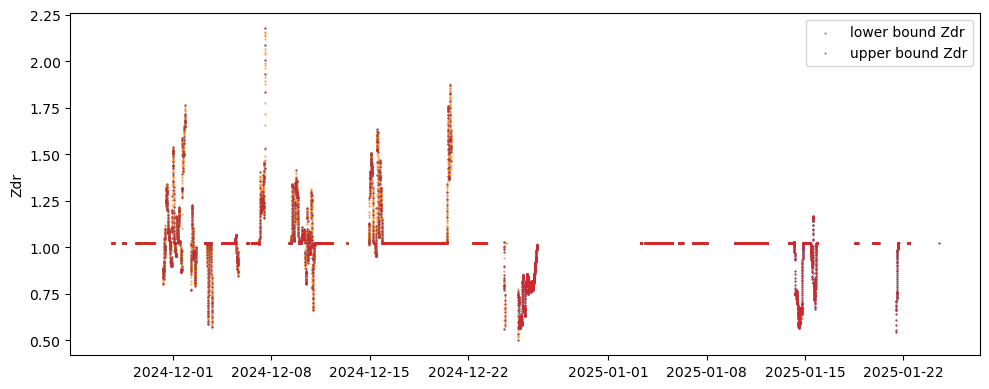

In [28]:
savefig = True
fig, ax = plt.subplots(1,1,figsize=(10,4))

ax.scatter(start_time + pd.to_timedelta(X_pred_not_ppi90, unit='m'), y_pred_not_ppi90, c='tab:orange', s=0.7, marker='.')
ax.scatter(start_time + pd.to_timedelta(X_pred_ppi90_low, unit='m'), y_pred_ppi90_low, c='tab:blue', s=0.7, marker='.', label='lower bound Zdr')
ax.scatter(start_time + pd.to_timedelta(X_pred_ppi90_upp, unit='m'), y_pred_ppi90_upp, c='tab:red', s=0.7, marker='.', label='upper bound Zdr')

plt.ylabel('Zdr')
plt.tight_layout()
plt.legend()

if savefig:
    out_fig_fname = f'{SAVE_DIR}/full_Zdr_correction_calculated_minmax_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

In [27]:
zdr_med_array = np.zeros(dt_array.shape)
zdr_std_array = np.zeros(dt_array.shape)

zdr_med_array[np.logical_not(ppi90_flag_list)] = y_pred_not_ppi90[0]
zdr_std_array[np.logical_not(ppi90_flag_list)] = y_std_not_ppi90[0]

zdr_med_array[ppi90_flag_list] = 0.5* (y_pred_ppi90_low[0] + y_pred_ppi90_upp[0])
zdr_std_array[ppi90_flag_list] = 0.5* (y_std_ppi90_low[0] + y_std_ppi90_upp[0])

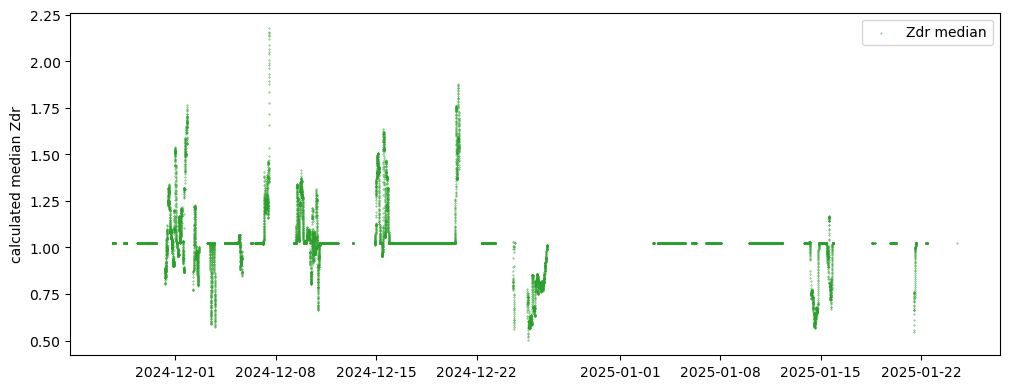

In [29]:
savefig = True

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.scatter(pd.to_datetime(dt_array, unit='s'), zdr_med_array, c='tab:green', s=0.4, marker='.', label='Zdr median')

plt.legend()
plt.tight_layout()
plt.ylabel('calculated median Zdr')

if savefig:
    out_fig_fname = f'{SAVE_DIR}/full_Zdr_correction_calculated_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

In [30]:
out_fname = 'corrections_%s_full.txt' % campaign_name
out_fpath = os.path.join(SAVE_DIR, out_fname)
with open(out_fpath, 'a') as out_f:
    #out_f.write('Datetime,correction[dB],STD[dB],3*STD[dB]\n')
    out_f.write('filename,datetime,correction_dB,std_dB\n')
    for i in range(len(dt_str_list)):
    #    out_f.write('%s,%.3f,%.4f,%.4f\n' % (dt_str_list[i], zdr_med_array[i],
    #                                         zdr_std_array[i], 3.*zdr_std_array[i]))
        out_f.write(f"{dt_str_list[i]},{pd.to_datetime(dt_array[i], unit='s')},{zdr_med_array[i]:.4f},{zdr_std_array[i]:.4f}\n")

In [31]:
dt_str_list

['XPOL-20241126-145220',
 'XPOL-20241126-145332',
 'XPOL-20241126-145444',
 'XPOL-20241126-145556',
 'XPOL-20241126-145706',
 'XPOL-20241126-145818',
 'XPOL-20241126-145930',
 'XPOL-20241126-151500',
 'XPOL-20241126-151612',
 'XPOL-20241126-151724',
 'XPOL-20241126-151836',
 'XPOL-20241126-152001',
 'XPOL-20241126-152105',
 'XPOL-20241126-152217',
 'XPOL-20241126-152329',
 'XPOL-20241126-152430',
 'XPOL-20241126-152542',
 'XPOL-20241126-152654',
 'XPOL-20241126-152756',
 'XPOL-20241126-152908',
 'XPOL-20241126-153103',
 'XPOL-20241126-153210',
 'XPOL-20241126-153323',
 'XPOL-20241126-153443',
 'XPOL-20241126-153713',
 'XPOL-20241126-153819',
 'XPOL-20241126-153932',
 'XPOL-20241126-154049',
 'XPOL-20241126-154313',
 'XPOL-20241126-154425',
 'XPOL-20241126-154539',
 'XPOL-20241126-154659',
 'XPOL-20241126-154931',
 'XPOL-20241126-155044',
 'XPOL-20241126-155158',
 'XPOL-20241126-155332',
 'XPOL-20241126-155604',
 'XPOL-20241126-155716',
 'XPOL-20241126-155830',
 'XPOL-20241126-155951',


In [32]:
pd.to_datetime(dt_array, unit='s')

DatetimeIndex(['2024-11-26 14:52:20', '2024-11-26 14:53:32',
               '2024-11-26 14:54:44', '2024-11-26 14:55:56',
               '2024-11-26 14:57:06', '2024-11-26 14:58:18',
               '2024-11-26 14:59:30', '2024-11-26 15:15:00',
               '2024-11-26 15:16:12', '2024-11-26 15:17:24',
               ...
               '2025-01-22 09:41:01', '2025-01-22 09:43:24',
               '2025-01-22 09:45:47', '2025-01-22 09:48:10',
               '2025-01-22 09:50:33', '2025-01-22 09:52:55',
               '2025-01-22 09:55:18', '2025-01-22 09:57:39',
               '2025-01-22 10:00:01', '2025-01-24 12:17:09'],
              dtype='datetime64[ns]', length=21333, freq=None)